## Домашнее задание к занятию "A/B-тесты"

### Описание задачи

![banner](https://storage.googleapis.com/kaggle-datasets-images/635/1204/126be74882028aac7241553cef0e27a7/dataset-original.jpg)

Покемоны - это маленькие существа, которые сражаются друг с другом на соревнованиях. Все покемоны имеют разные характеристики (сила атаки, защиты и т. д.) И относятся к одному или двум так называемым классам (вода, огонь и т. д.).
Профессор Оук является изобретателем Pokedex - портативного устройства, которое хранит информацию обо всех существующих покемонах. Как его ведущий специалист по данным, Вы только что получили от него запрос с просьбой осуществить аналитику данных на всех устройствах Pokedex.

### Описание набора данных
Профессор Оук скопировал все содержимое в память одного устройства Pokedex, в результате чего получился набор данных, с которым Вы будете работать в этой задаче. В этом файле каждая строка представляет характеристики одного покемона:

* `pid`: Numeric - ID покемона
* `HP`: Numeric - Очки здоровья
* `Attack`: Numeric - Сила обычной атаки
* `Defense`: Numeric - Сила обычной защиты
* `Sp. Atk`: Numeric - Сила специальной атаки
* `Sp. Def`: Numeric - Сила специальной защиты
* `Speed`: Numeric - Скорость движений
* `Legendary`: Boolean - «True», если покемон редкий
* `Class 1`: Categorical - Класс покемона
* `Class 2`: Categorical - Класс покемона

In [1]:
import warnings
from cProfile import label

from IPython.core.pylabtools import print_figure

# Отключение предупреждений (warnings)
warnings.filterwarnings("ignore")

import pandas as pd

from scipy.stats import ttest_ind
from scipy.stats import f_oneway, shapiro

pokemon = pd.read_csv('https://raw.githubusercontent.com/a-milenkin/datasets_for_t-tests/main/pokemon.csv', on_bad_lines='skip')  # Откроем датасет
pokemon.head()

# Обратите внимание, что у покемона может быть один или два класса.
# Если у покемона два класса, считается, что они имеют одинаковую значимость.

,pid,Name,Class 1,Class 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,False


### Задачи

<div class="alert alert-info">
<b>Задание № 1:</b>
    
Профессор Оук подозревает, что покемоны в классе `Grass` имеют более сильную обычную атаку, чем покемоны в классе `Rock`. Проверьте, прав ли он, и убедите его в своём выводе статистически.
    
    
Примечание: если есть покемоны, которые относятся к обоим классам, просто выбросьте их;
    
Вы можете предположить, что распределение обычных атак является нормальным для всех классов покемонов.

</div>

сперва исключить связку Grass/Rock затем проверить на нормальность(не обязательно) и затем проверяем гипотезу о более сильной атаке h0/h1

Здесь мы исключаем из выборки покемонов с типомс атаки ROCK.

 берем Grass в одном из двух классов, и исключаем в 1 и 2 столбцах классов.

In [2]:
pokemon_grass = pokemon[
    ( (pokemon['Class 1'] == 'Grass') | (pokemon['Class 2'] == 'Grass') ) &
    ( (pokemon['Class 1'] != 'Rock') & (pokemon['Class 2'] != 'Rock') )
]
pokemon_grass.head()

,pid,Name,Class 1,Class 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,False
48,49,Oddish,Grass,Poison,45,50,55,75,65,30,False


выводим атаку типа Grass

In [3]:
grass_attack = pokemon_grass['Attack']
grass_attack.head()

0      49
1      62
2      82
3     100
48     50
Name: Attack, dtype: int64

аналогично для ROCK исключаем Grass

In [4]:
pokemon_rock = pokemon[
    ( (pokemon['Class 1'] == 'Rock' ) | (pokemon['Class 2'] == 'Rock' ) ) &
    ( (pokemon['Class 1'] != 'Grass') & (pokemon['Class 2'] != 'Grass') )
]

pokemon_rock.head()

,pid,Name,Class 1,Class 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Legendary
80,81,Geodude,Rock,Ground,40,80,100,30,30,20,False
81,82,Graveler,Rock,Ground,55,95,115,45,45,35,False
82,83,Golem,Rock,Ground,80,120,130,55,65,45,False
103,104,Onix,Rock,Ground,35,45,160,30,45,70,False
119,120,Rhyhorn,Ground,Rock,80,85,95,30,30,25,False


In [5]:
rock_attack = pokemon_rock['Attack']
rock_attack.head()

80      80
81      95
82     120
103     45
119     85
Name: Attack, dtype: int64

In [27]:
# необязательная проверка на нормальность(для себя)
# проверяем длинну выборок, для выявления будем ли мы использовать тест-Шапиро или другой N > 1000 или N > 5000
print(f'длинна выборки класса Grass: {(len(grass_attack))}\n'
      f'длинна выборки класса Rock: {(len(rock_attack))}'
)
if len(grass_attack) < 1000 and len(rock_attack) < 1000:
    print(f'тест Шапиро подходит для определения нормальности выборки')
else:
    print(f'ПРИМЕНЯЙ другой тест')

длинна выборки класса Grass: 93
длинна выборки класса Rock: 56
тест Шапиро подходит для определения нормальности выборки


In [7]:
import scipy.stats as stats
#создаем функцию для проверки нормальности тест Шапиро
def is_normal_distribution(data):
    stat, p_value = shapiro(data)
    if p_value < 0.05:
        return print(f'p-value: {p_value} отвергаем h0, данные распределены НЕнормально')
    else:
        return print(f'p-value: {p_value} отвергаем h1, данные распределены нормально')

In [8]:
is_normal_distribution(rock_attack)
is_normal_distribution(grass_attack)

p-value: 0.5855139007055862 отвергаем h1, данные распределены нормально
p-value: 0.11250248749760611 отвергаем h1, данные распределены нормально


Раз данные у нас распределены нормально и мы проверили это только что, то приступаем к проверке гипотезе из условия задачи:
Для этого будем использовать t-тест Стьюдента

In [17]:
'''
проверяем гипотезу:
"покемоны в классе `A` статистическое лучше по-заданному критерию, чем покемоны в классе `B`."

h0 - Гипотеза Профессора Оука статистически НЕ подтверждается
h1 - Гипотеза Профессора Оука статистически подтверждается
'''

def t_test_student(data1, data2, alpha=0.05):
    stat, p_value = stats.ttest_ind(data1, data2, alternative="greater")

    print(f"t-статистика: {stat:.4f}")
    print(f"p-value: {p_value:.6f}")

    if p_value < alpha:
        print(f'результат: отвергаем h0 в Профессор Оук прав гипотеза статистически подтверждается')
    else:
        print(f'Результат: Не удалось отвергнуть H0. Гипотеза Профессора Оука НЕ подтвердилась.')

In [16]:
t_test_student(grass_attack, rock_attack)

t-статистика: -3.7295
p-value: 0.999863
Результат: Не удалось отвергнуть H0. Гипотеза Профессора Оука НЕ подтвердилась.


посмотрим на ряды выборок по атакам в графической части:

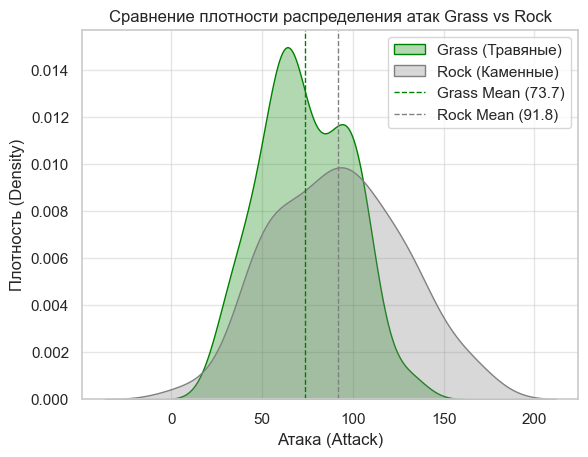

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Построение графиков плотности (KDE)

#устанавливаем стиль оформления:
sns.set_theme(style="whitegrid")

# 1. Кривая плотности для Grass
sns.kdeplot(
    grass_attack, # закрашивает область под кривой для наглядности.
    fill=True,
    label='Grass (Травяные)', # задаёт название группы, которое потом отобразится в легенде.
    color='green',
    alpha=0.3 # делает заливку прозрачной, чтобы в месте пересечения графиков всё было хорошо видно.
)

# 2. Кривая плотности для Rock
sns.kdeplot(
    rock_attack,
    fill=True,
    label='Rock (Каменные)',
    color='gray',
    alpha=0.3
)

# 3. Считаем средние
mean_grass = grass_attack.mean()
mean_rock = rock_attack.mean()

# 4. Рисуем пунктирные линии средних значений
plt.axvline(
    mean_grass,
    color='green',
    linestyle='--',
    linewidth=1,
    label=f'Grass Mean ({mean_grass:.1f})'
)
plt.axvline(
    mean_rock,
    color='gray',
    linestyle='--',
    linewidth=1,
    label=f'Rock Mean ({mean_rock:.1f})'
)

# 5. Включаем легенду и заголовок
plt.title('Сравнение плотности распределения атак Grass vs Rock')
plt.xlabel('Атака (Attack)')
plt.ylabel('Плотность (Density)')
plt.legend()

Несмотря на то, что плотность распределения у группы Grass выше в значениях 50-100, за счет большего размаха и более тяжелых хвостов группа Rock имеют большее среднее значение. Графиком мы подтвердили математический вывод: Гипотеза Профессора Оука НЕ подтвердилась.

на графике kde у нас видны два пика, чтобы проверить бимодальность, нужно построить гистограмму:

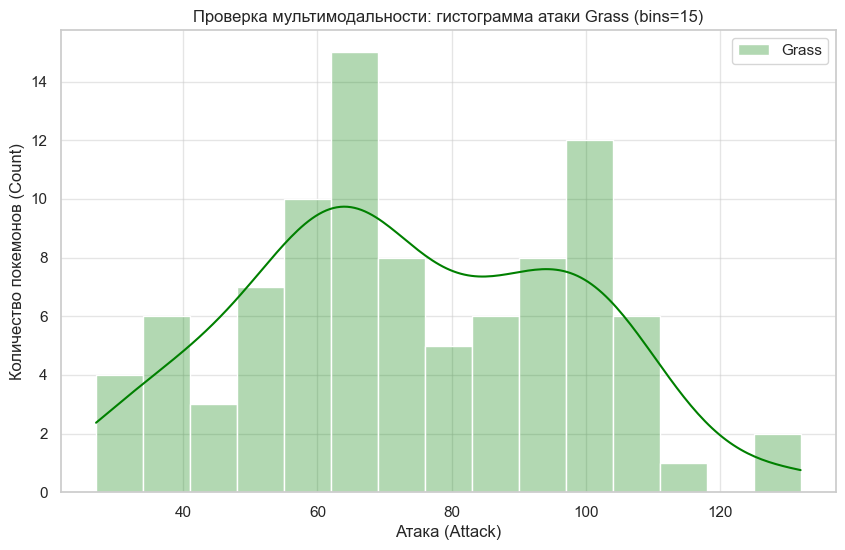

In [12]:
# Настройка холста
plt.figure(figsize=(10, 6))
sns.set_theme(style='whitegrid')

# Гистограмма для Grass с реальными бинами (столбиками)
sns.histplot(
    grass_attack,
    color='green',  # Цвет столбиков
    alpha=0.3,  # Прозрачность столбиков
    kde=True,  # Накладываем линию сглаживания
    bins=15,  # Делим данные на 15 интервалов (столбиков)
    label='Grass',
)

# Оформление
plt.title(
    'Проверка мультимодальности: гистограмма атаки Grass (bins=15)', fontsize=12
)
plt.xlabel('Атака (Attack)')
plt.ylabel('Количество покемонов (Count)')
plt.legend()

plt.show()

вот у нас 1 пик в районе 60-70 потом спад и снова 2 пик в райноне 100. График бимодальный

<div class="alert alert-info">
<b>Задание № 2:</b>
    
Профессор Оук уже долго не может спать по ночам, ведь его волнует вопрос, а правда ли, что покемоны в классе `Water` в среднем быстрее, чем покемоны в классе `Normal`.
    
    
Проверьте, прав ли он, и убедите его в своём выводе статистически.
    
Примечание: если есть покемоны, которые относятся к обоим классам, выбросьте их;
    
Вы можете предположить, что распределение скорости движения является нормальным для всех классов покемонов.
</div>

Проводом аналогичные действия как в задаче один по исключению классов и формированию двух выборок:

In [18]:
pokemon_water = pokemon[
    ( (pokemon['Class 1'] == 'Water') | (pokemon['Class 2'] == 'Water') ) &
    ( (pokemon['Class 1'] != 'Normal') & (pokemon['Class 2'] != 'Normal') )
]
pokemon_water.head()

,pid,Name,Class 1,Class 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Legendary
9,10,Squirtle,Water,NaN,44,48,65,50,64,43,False
10,11,Wartortle,Water,NaN,59,63,80,65,80,58,False
11,12,Blastoise,Water,NaN,79,83,100,85,105,78,False
12,13,Mega Blastoise,Water,NaN,79,103,120,135,115,78,False
59,60,Psyduck,Water,NaN,50,52,48,65,50,55,False


In [19]:
water_speed = pokemon_water['Speed']
water_speed.head()

9     43
10    58
11    78
12    78
59    55
Name: Speed, dtype: int64

In [20]:
pokemon_normal = pokemon[
    ( (pokemon['Class 1'] == 'Normal') | (pokemon['Class 2'] == 'Normal') ) &
    ( (pokemon['Class 1'] != 'Water') & (pokemon['Class 2'] != 'Water') )
]
pokemon_normal.head()

,pid,Name,Class 1,Class 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Legendary
20,21,Pidgey,Normal,Flying,40,45,40,35,35,56,False
21,22,Pidgeotto,Normal,Flying,63,60,55,50,50,71,False
22,23,Pidgeot,Normal,Flying,83,80,75,70,70,101,False
23,24,Mega Pidgeot,Normal,Flying,83,80,80,135,80,121,False
24,25,Rattata,Normal,NaN,30,56,35,25,35,72,False


In [21]:
normal_speed = pokemon_normal['Speed']
normal_speed.head()

20     56
21     71
22    101
23    121
24     72
Name: Speed, dtype: int64

In [22]:
is_normal_distribution(water_speed)
is_normal_distribution(normal_speed)

p-value: 0.5009101956292257 отвергаем h1, данные распределены нормально
p-value: 0.49682286709410317 отвергаем h1, данные распределены нормально


In [23]:
t_test_student(water_speed, normal_speed)

t-статистика: -2.1509
p-value: 0.983723
Результат: Не удалось отвергнуть H0. Гипотеза Профессора Оука НЕ подтвердилась.


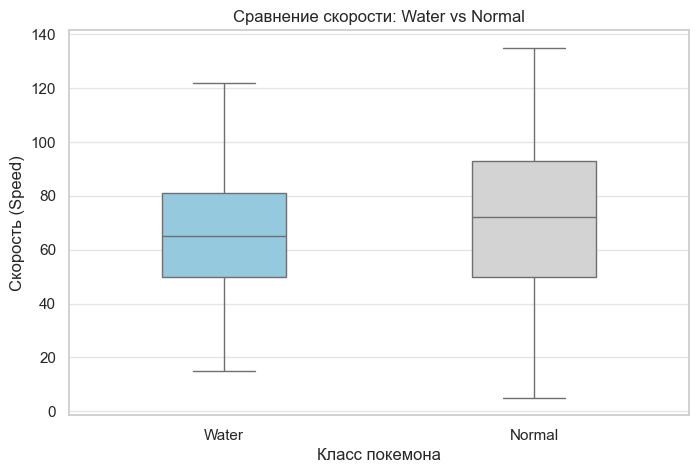

In [30]:
df_plot = pd.DataFrame(
    {
        'Speed': pd.concat([water_speed, normal_speed]),
        'Type': ['Water'] * len(water_speed) + ['Normal'] * len(normal_speed),
    }
)

# 2. Строим график
plt.figure(figsize=(8, 5))
sns.set_theme(style='whitegrid')

sns.boxplot(
    data=df_plot,
    x='Type',
    y='Speed',
    palette=['skyblue', 'lightgray'],
    width=0.4,
)

plt.title('Сравнение скорости: Water vs Normal')
plt.xlabel('Класс покемона')
plt.ylabel('Скорость (Speed)')

plt.show()

<div class="alert alert-info">
<b>Задание № 3:</b>
    
Профессор Оук тот еще безумец. Он изобрёл сыворотку, способную ускорить покемона. Однако мы усомнились в эффективности его вакцины. Професоор дал эту сыворотку следующим покемонам: смотри массив `treathed_pokemon`. Проверьте, работает ли вообще его сыворотка, убедите всех в своём выводе статистически.
    
    
Вы можете предположить, что распределение скорости движения является нормальным для всех классов покемонов.

</div>

In [13]:
# Покемоны, которые принимали сыворотку увеличения скорости
treathed_pokemon = ['Mega Beedrill', 'Mega Alakazam',
                    'Deoxys Normal Forme', 'Mega Lopunny']

In [39]:
treathed_df = pokemon[pokemon['Name'].isin(treathed_pokemon)]
treathed_df

,pid,Name,Class 1,Class 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Legendary
19,20,Mega Beedrill,Bug,Poison,65,150,40,15,80,145,False
71,72,Mega Alakazam,Psychic,NaN,55,50,65,175,95,150,False
428,429,Deoxys Normal Forme,Psychic,NaN,50,150,50,150,50,150,True
476,477,Mega Lopunny,Normal,Fighting,65,136,94,54,96,135,False


In [31]:
# Вытаскиваем их скорость
treated_speed = pokemon[pokemon['Name'].isin(treathed_pokemon)]['Speed']
treated_speed.head()

19     145
71     150
428    150
476    135
Name: Speed, dtype: int64

In [32]:
# Скорость всех остальных покемонов
untreated_speed = pokemon[~pokemon['Name'].isin(treathed_pokemon)]['Speed']
untreated_speed.head()

0    45
1    60
2    80
3    80
4    65
Name: Speed, dtype: int64

Попробуем использовать Одновыборочный тест (stats.ttest_1samp). тк данные нормальные. у нас есть 4 покемона для сравнения их средней скорости со средней скоростью всех остальных покемонов:

In [35]:
# 3. Считаем чистый эталон по контрольной группе
clean_pop_mean = untreated_speed.mean()
clean_pop_mean

np.float64(67.89195979899498)

In [38]:
# 4. Проводим 1-sample t-test
stat, p_value = stats.ttest_1samp(treated_speed, popmean=clean_pop_mean, alternative='greater')
print(f"t-статистика: {stat:.4f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print(f'результат: отвергаем h0 в Профессор Оук прав гипотеза статистически подтверждается')
else:
    print(f'Результат: Не удалось отвергнуть H0. Гипотеза Профессора Оука НЕ подтвердилась.')

t-статистика: 21.8094
p-value: 0.000105
результат: отвергаем h0 в Профессор Оук прав гипотеза статистически подтверждается


#### Вывод:
Статистически гипотеза подтверждается, но мы не можем с уверенностью сказать, что причина роста скорости покемонов это именно действие сыворотки.
Возможно сама природа покемонов из списка "treathed_pokemon" является причиной куда большей скорости, на это могет указывать название покемонов в три из них имеют приставку "Mega", что может говорить об уровне эволюции покемона, а также покемон с названием 'Deoxys Normal Forme' вообще имеет "Легендарный" тип.
Для более точных выводов нам нужны дополнительные данные, например скорость до применения сыворотки, чтобы мы могли провести прямое сравнение скорости ДО и ПОСЛЕ. Например А/Б-тестом или просто сравнением средних значений до и после

<div class="alert alert-info">
<b>Задание № 4:</b>
    
Профессор Оук всегда любил истории про легендарных покемонов. Однако профессор не очень уверен, что они лучше остальных покемонов. Оук предложил разобраться в этом нам. Проверьте, действительно ли сумма характеристик `HP`,`Attack`,`Defense` у легендарных покемонов выше, чем у других покемонов?

А произведение этих же параметров?

Найдите ответы на эти вопросы и убедите всех в своём выводе статистически.
   

Вы можете предположить, что распределение сум и произведений этих параметров является нормальным для всех классов покемонов.

</div>

Создадим новые колонки для сравнения сумму статов и произведение статов:

In [40]:
pokemon['stats_sum'] = pokemon['HP'] + pokemon['Attack'] + pokemon['Defense']
pokemon['stats_prod'] = pokemon['HP'] * pokemon['Attack'] * pokemon['Defense']
pokemon.head()

,pid,Name,Class 1,Class 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Legendary,stats_sum,stats_prod
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,False,143,108045
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,False,185,234360
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,False,245,544480
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,False,303,984000
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,False,134,87204


In [43]:
# вывод легендарных покемонов
legendary = pokemon[pokemon['Legendary'] == True]
legendary

,pid,Name,Class 1,Class 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Legendary,stats_sum,stats_prod
156,157,Articuno,Ice,Flying,90,85,100,95,125,85,True,275,765000
157,158,Zapdos,Electric,Flying,90,90,85,125,90,100,True,265,688500
158,159,Moltres,Fire,Flying,90,100,90,125,85,90,True,280,810000
162,163,Mewtwo,Psychic,NaN,106,110,90,154,90,130,True,306,1049400
163,164,Mega Mewtwo X,Psychic,Fighting,106,190,100,154,100,130,True,396,2014000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,Diancie,Rock,Fairy,50,100,150,100,150,50,True,300,750000
796,797,Mega Diancie,Rock,Fairy,50,160,110,160,110,110,True,320,880000
797,798,Hoopa Confined,Psychic,Ghost,80,110,60,150,130,70,True,250,528000
798,799,Hoopa Unbound,Psychic,Dark,80,160,60,170,130,80,True,300,768000


In [44]:
non_legendary = pokemon[pokemon['Legendary'] == False]
non_legendary

,pid,Name,Class 1,Class 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Legendary,stats_sum,stats_prod
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,False,143,108045
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,False,185,234360
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,False,245,544480
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,False,303,984000
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,False,134,87204
...,...,...,...,...,...,...,...,...,...,...,...,...,...
787,788,Gourgeist Super Size,Ghost,Grass,85,100,122,58,75,54,False,307,1037000
788,789,Bergmite,Ice,NaN,55,69,85,32,35,28,False,209,322575
789,790,Avalugg,Ice,NaN,95,117,184,44,46,28,False,396,2045160
790,791,Noibat,Flying,Dragon,40,30,35,45,40,55,False,105,42000


In [46]:
# средняя сумма:
print(f'средняя сумма "Легендарные": {legendary['stats_sum'].mean():.2f}\n'
      f'средняя сумма "обычные": {non_legendary['stats_sum'].mean():.2f}'
)

# среднее произведение:
print(f'среднее произведение "Легендарные": {legendary['stats_prod'].mean():.2f}\n'
      f'среднее произведение "обычные": {non_legendary['stats_prod'].mean():.2f}'
)

средняя сумма "Легендарные": 309.08
средняя сумма "обычные": 214.41
среднее произведение "Легендарные": 1085941.62
среднее произведение "обычные": 425041.39


проведем статистическую проверку гипотез:

In [54]:
'''
h0 - Средняя сумма параметров у легендарных покемонов меньше или равна средней сумме у обычных
h1 - Средняя сумма параметров у легендарных покемонов строго больше
'''
# Воспользуемся t-тестом Уэлча (тк длинна выборок разная и разброс дисперсий будет разный):

#для суммы характеристик:
stat_sum, p_value_sum = stats.ttest_ind(legendary['stats_sum'], non_legendary['stats_sum'], alternative='greater', equal_var=False)

print(f'для суммы характеристик t-статистика: {stat_sum:.4f},'
      f'p-value: {p_value_sum:.2e}')

# для произведения характеристик:
stat_prod, p_value_prod = stats.ttest_ind(legendary['stats_prod'], non_legendary['stats_prod'], alternative='greater', equal_var=False)

print(f'для произведения характеристик t-статистика: {stat_prod:.4f},'
      f'p-value: {p_value_prod:.2e}')


для суммы характеристик t-статистика: 15.1976,p-value: 1.46e-26
для произведения характеристик t-статистика: 10.0791,p-value: 1.45e-15


Хоть и на вычисленных средних сумм и произведений характеристик было видно, что разница параметров была ощутимой. Теперь мы видим, что p-value для сумм и произведений параметров колосально низок и стремится к нулю, что в свою очередь статистичеки подтверждает гипотезу профессора Оука о том, что характеристики легендарных покемонов выше, чем у обычных!

<div class="alert alert-info">
<b>Задание № 5:</b>
    
Профессор Оук частенько наблюдает за боями покемонов. После очередных таких боёв Оук выделил четыре класса `best_defence_class`, которые на его взгляд одинаковы по "силе обычной защиты" `Defense`.

Проверьте, действительно ли эти классы покемонов не отличаются по уровню защиты статистически значимо? Всё та же статистика вам в помощь!
   

Вы можете предположить, что распределение параметров защитных характеристик является нормальным для всех классов покемонов.

</div>

In [14]:
best_defence_class = ['Rock', 'Ground', 'Steel', 'Ice']
best_defence_class

['Rock', 'Ground', 'Steel', 'Ice']

выведем показатель защиты для всех 4 групп покемонов:

In [56]:
# Фильтруем только по первому (основному) классу
rock_def = pokemon[pokemon['Class 1'] == 'Rock']['Defense']
ground_def = pokemon[pokemon['Class 1'] == 'Ground']['Defense']
steel_def = pokemon[pokemon['Class 1'] == 'Steel']['Defense']
ice_def = pokemon[pokemon['Class 1'] == 'Ice']['Defense']

In [57]:
#Фильтруем по 2 классам
rock_def2 = pokemon[
    (pokemon['Class 1'] == 'Rock') | (pokemon['Class 2'] == 'Rock')
]['Defense']
ground_def2 = pokemon[
    (pokemon['Class 1'] == 'Ground') | (pokemon['Class 2'] == 'Ground')
]['Defense']
steel_def2 = pokemon[
    (pokemon['Class 1'] == 'Steel') | (pokemon['Class 2'] == 'Steel')
]['Defense']
ice_def2 = pokemon[
    (pokemon['Class 1'] == 'Ice') | (pokemon['Class 2'] == 'Ice')
]['Defense']

In [71]:
def test_oneway(*data, alpha=0.05):
    stat, p_value = stats.f_oneway(*data)

    print(f'stat: {stat:.4f},\n'
          f'p_value: {p_value:.2e}')

    if p_value > alpha:
        print(f'h0 - покемоны в этих классах не отличаются по параметрам, при этом h1 отвергаем')
    else:
        print(f'h1 - покемоны в этих классах отличаются по параметрам, при этом отвергаем h0')

In [72]:
# проверим защиту по 1 основному классу:
test_oneway(rock_def, ground_def, steel_def, ice_def)

stat: 10.5769,
p_value: 3.08e-06
h1 - покемоны в этих классах отличаются по параметрам, при этом отвергаем h0


In [73]:
# проверим защиту покемонов по 2 классам:
test_oneway(rock_def2, ground_def2, steel_def2, ice_def2)

stat: 10.8201,
p_value: 1.23e-06
h1 - покемоны в этих классах отличаются по параметрам, при этом отвергаем h0


Гипотеза профессора Оука статистически опровергнута h0 что все покемоны в 4 группах имеют одинаковую защиту.

Попробуем найти конкретные отличия в 4 группаз покемонов:

In [74]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. Отбираем покемонов только нужных 4 классов
best_defence_classes = ['Rock', 'Ground', 'Steel', 'Ice']
df_filtered = pokemon[pokemon['Class 1'].isin(best_defence_classes)]

# 2. Запускаем Tukey HSD test
tukey = pairwise_tukeyhsd(
    endog=df_filtered['Defense'],  # Числовая переменная
    groups=df_filtered['Class 1'],  # Категориальная переменная
    alpha=0.05,
)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
Ground    Ice -13.4271 0.5457 -39.7195 12.8653  False
Ground   Rock  15.9517 0.2613  -6.6698 38.5733  False
Ground  Steel  41.5266 0.0002  16.0826 66.9707   True
   Ice   Rock  29.3788 0.0128   4.6707 54.0869   True
   Ice  Steel  54.9537    0.0  27.6379 82.2695   True
  Rock  Steel  25.5749   0.03   1.7716 49.3783   True
-----------------------------------------------------


Профессор Оук был прав в том, что Ground, Ice и Rock достаточно близки по защите (между Ground и Ice, а также между Ground и Rock разницы нет). Но он сильно переоценил Лёд и недооценил Сталь: Steel — безусловный лидер с гигантским отрывом, а Ice — самый слабый по защите в этой четвёрке.